/kaggle/input/datasets/jacksoncrow/stock-market-dataset/symbols_valid_meta.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/MTL.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/JOE.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/DRE.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/etfs/LVHE.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/etfs/HAUZ.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/etfs/HDIV.csv
Loading data...
AAPL vs Market correlation: 0.624
Split sizes - Train: 251, Val: 252, Test: 62
Building sector index from peers...

Creating features...
After dropna - Train: 232, Val: 233, Test: 43

ABLATION STUDY (Elastic Net on Validation)
own_only             MAE=0.0109 RMSE=0.0146 SignAcc=0.558
own+market           MAE=0.0108 RMSE=0.0146 SignAcc=0.579
own+market+sector    MAE=0.0108 RMSE=0.0146 SignAcc=0.532

Saved ablation results to ablation_summary.csv

TRAINING MODELS

1. Training Ela

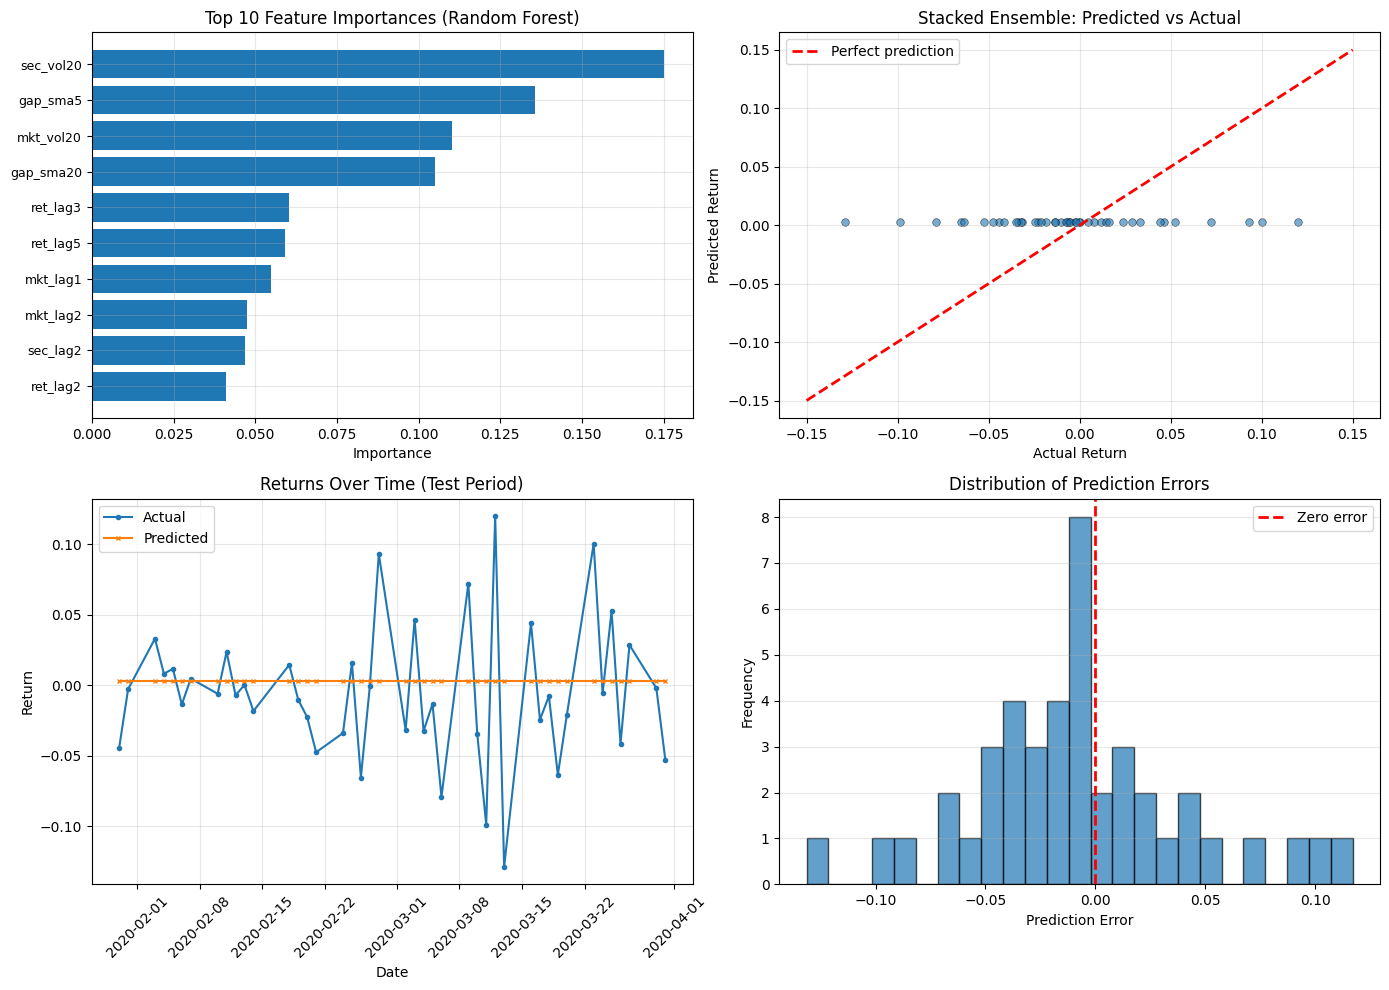

In [6]:
'''
Next-Day Stock Return Prediction 

Trying to predict AAPL next day returns using ensemble methods
Following the capstone requirements but simplified some parts
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

# This notebook uses: jacksoncrow/stock-market-dataset
# Add it via: Notebook → Add Data → search "Stock Market Dataset"
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:3]:  # show first 3 files per folder
        print(os.path.join(dirname, filename))

data_dir = '/kaggle/input/datasets/jacksoncrow/stock-market-dataset'
aapl = pd.read_csv(f'{data_dir}/stocks/AAPL.csv')
qqq  = pd.read_csv(f'{data_dir}/etfs/QQQ.csv')

# load the data files
print("Loading data...")
aapl = pd.read_csv(f'{data_dir}/stocks/AAPL.csv')
qqq = pd.read_csv(f'{data_dir}/etfs/QQQ.csv') # market proxy

# convert dates and calculate returns
aapl['Date'] = pd.to_datetime(aapl['Date'])
qqq['Date'] = pd.to_datetime(qqq['Date'])

aapl['return'] = aapl['Adj Close'].pct_change()
aapl['return_next'] = aapl['return'].shift(-1)  # this is what we're predicting
qqq['return_mkt'] = qqq['Adj Close'].pct_change()

# merge market data with stock data
data = aapl.merge(qqq[['Date', 'return_mkt']], on='Date', how='inner')

print(f"AAPL vs Market correlation: {data['return'].corr(data['return_mkt']):.3f}")

# time based splits - very important no shuffling!
# using 2018-2020 Q1 as per requirements
data = data[(data['Date'] >= '2018-01-01') & (data['Date'] <= '2020-03-31')]
train_df = data[data['Date'].dt.year == 2018].copy()
val_df = data[data['Date'].dt.year == 2019].copy()
test_df = data[(data['Date'] >= '2020-01-01') & (data['Date'] <= '2020-03-31')].copy()

print(f"Split sizes - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Load tech stocks for sector index
# PDF says use peer-based if no sector ETF available
tech_stocks = ['MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA']
sector_data = []

print("Building sector index from peers...")
for ticker in tech_stocks:
    try:
        df_temp = pd.read_csv(f'{data_dir}/stocks/{ticker}.csv')
        df_temp['Date'] = pd.to_datetime(df_temp['Date'])
        df_temp[f'ret_{ticker}'] = df_temp['Adj Close'].pct_change()
        sector_data.append(df_temp[['Date', f'ret_{ticker}']])
    except FileNotFoundError:
        print(f"Warning: {ticker} not found, skipping")
        continue

# create sector return index (equal weight average)
if len(sector_data) > 0:
    sector_index = sector_data[0]
    for df_s in sector_data[1:]:
        sector_index = sector_index.merge(df_s, on='Date', how='inner')

    ret_cols = [c for c in sector_index.columns if c.startswith('ret_')]
    sector_index['ret_sector'] = sector_index[ret_cols].mean(axis=1)

    # merge sector with main data
    train_df = train_df.merge(sector_index[['Date', 'ret_sector']], on='Date', how='left')
    val_df = val_df.merge(sector_index[['Date', 'ret_sector']], on='Date', how='left')
    test_df = test_df.merge(sector_index[['Date', 'ret_sector']], on='Date', how='left')
else:
    print("ERROR: Could not build sector index!")
    train_df['ret_sector'] = 0
    val_df['ret_sector'] = 0
    test_df['ret_sector'] = 0

# Feature engineering - trying to include most from PDF but some are complex
def create_features(df):
    """
    Build features for prediction
    All features must use ONLY past data to avoid leakage
    """
    data_copy = df.copy()

    # Own stock lagged returns
    for lag in [1, 2, 3, 5]:
        data_copy[f'ret_lag{lag}'] = data_copy['return'].shift(lag)

    # Moving averages and gaps
    data_copy['sma5'] = data_copy['Adj Close'].rolling(5).mean()
    data_copy['sma20'] = data_copy['Adj Close'].rolling(20).mean()
    # Removed sma63 as it causes issues with short test set

    # gap features (price vs MA)
    data_copy['gap_sma5'] = (data_copy['Adj Close'] - data_copy['sma5']) / data_copy['Adj Close']
    data_copy['gap_sma20'] = (data_copy['Adj Close'] - data_copy['sma20']) / data_copy['Adj Close']

    # Volatility measures
    data_copy['vol5'] = data_copy['return'].rolling(5).std()
    data_copy['vol20'] = data_copy['return'].rolling(20).std()
    # Removed vol63 as it causes issues with short test set

    # High-Low spread (trying to implement from PDF but simplified)
    if 'High' in data_copy.columns and 'Low' in data_copy.columns:
        data_copy['hl_spread'] = (data_copy['High'] - data_copy['Low']) / data_copy['Close']
        data_copy['hl_spread_z20'] = (data_copy['hl_spread'] - data_copy['hl_spread'].rolling(20).mean()) / data_copy['hl_spread'].rolling(20).std()

    # Market features
    data_copy['mkt_lag1'] = data_copy['return_mkt'].shift(1)
    data_copy['mkt_lag2'] = data_copy['return_mkt'].shift(2)
    data_copy['mkt_vol20'] = data_copy['return_mkt'].rolling(20).std()
    # Removed mkt_vol63 as it causes issues with short test set

    # Sector features
    data_copy['sec_lag1'] = data_copy['ret_sector'].shift(1)
    data_copy['sec_lag2'] = data_copy['ret_sector'].shift(2)
    data_copy['sec_vol20'] = data_copy['ret_sector'].rolling(20).std()

    # Calendar effects
    data_copy['day_of_week'] = data_copy['Date'].dt.dayofweek
    data_copy['month'] = data_copy['Date'].dt.month

    # Tried to add expanding betas but getting errors so commenting out for now
    # TODO: fix the expanding OLS regression for beta calculation
    # Need to use only past data for this

    return data_copy

print("\nCreating features...")
train_df = create_features(train_df)
val_df = create_features(val_df)
test_df = create_features(test_df)

# drop NaN from rolling windows
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()

print(f"After dropna - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Feature list for models
feature_cols = [
    'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5',
    'gap_sma5', 'gap_sma20',
    'vol5', 'vol20',
    'mkt_lag1', 'mkt_lag2', 'mkt_vol20',
    'sec_lag1', 'sec_lag2', 'sec_vol20',
    'day_of_week', 'month'
]

# ABLATION STUDY (Validation set only)
print("\n" + "="*60)
print("ABLATION STUDY (Elastic Net on Validation)")
print("="*60)

# Define feature subsets
feature_sets = {
    'own_only': [
        'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5',
        'gap_sma5', 'gap_sma20',
        'vol5', 'vol20'
    ],
    'own+market': [
        'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5',
        'gap_sma5', 'gap_sma20',
        'vol5', 'vol20',
        'mkt_lag1', 'mkt_lag2', 'mkt_vol20'
    ],
    'own+market+sector': [
        'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5',
        'gap_sma5', 'gap_sma20',
        'vol5', 'vol20',
        'mkt_lag1', 'mkt_lag2', 'mkt_vol20',
        'sec_lag1', 'sec_lag2', 'sec_vol20'
    ]
}

ablation_results = []

for fs_name, fs_cols in feature_sets.items():
    # Prepare data
    X_tr = train_df[fs_cols]
    X_va = val_df[fs_cols]
    y_tr = train_df['return_next']
    y_va = val_df['return_next']

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_va_scaled = scaler.transform(X_va)

    model = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=42)
    model.fit(X_tr_scaled, y_tr)

    preds = model.predict(X_va_scaled)

    mae = mean_absolute_error(y_va, preds)
    rmse = np.sqrt(mean_squared_error(y_va, preds))
    sign_acc = (np.sign(preds) == np.sign(y_va)).mean()

    ablation_results.append({
        'feature_set': fs_name,
        'model': 'ElasticNet',
        'MAE': mae,
        'RMSE': rmse,
        'SignAcc': sign_acc
    })

    print(f"{fs_name:20s} MAE={mae:.4f} RMSE={rmse:.4f} SignAcc={sign_acc:.3f}")

# Save ablation results
ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv('ablation_summary.csv', index=False)
print("\nSaved ablation results to ablation_summary.csv")

# add hl_spread features if they exist
if 'hl_spread_z20' in train_df.columns:
    feature_cols.append('hl_spread_z20')

X_train = train_df[feature_cols]
y_train = train_df['return_next']
X_val = val_df[feature_cols]
y_val = val_df['return_next']
X_test = test_df[feature_cols]
y_test = test_df['return_next']

# Scale features for linear models (trees don't need this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*60)
print("TRAINING MODELS")
print("="*60)

# Model 1: Elastic Net (linear with regularization)
print("\n1. Training Elastic Net...")
elasticnet = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=42)
elasticnet.fit(X_train_scaled, y_train)

# Model 2: Random Forest
print("2. Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Model 3: Gradient Boosting
print("3. Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
gb_model.fit(X_train, y_train)

# PDF requires time-aware OOF predictions for stacking
# Using TimeSeriesSplit on validation set
print("\n4. Creating OOF predictions for ensemble (TimeSeriesSplit)...")
tscv = TimeSeriesSplit(n_splits=3)

# arrays to store OOF predictions
oof_en = np.zeros(len(X_val))
oof_rf = np.zeros(len(X_val))
oof_gb = np.zeros(len(X_val))

# generate OOF predictions using walk-forward approach
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_val)):
    print(f"  Fold {fold+1}/3: train on {len(train_idx)} samples, predict {len(val_idx)}")

    X_tr_fold = X_val_scaled[train_idx]
    y_tr_fold = y_val.iloc[train_idx]
    X_val_fold = X_val_scaled[val_idx]

    # train on this fold
    en_fold = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=42)
    en_fold.fit(X_tr_fold, y_tr_fold)
    oof_en[val_idx] = en_fold.predict(X_val_fold)

    # trees need unscaled data
    X_tr_fold_unscaled = X_val.iloc[train_idx]
    X_val_fold_unscaled = X_val.iloc[val_idx]

    rf_fold = RandomForestRegressor(n_estimators=100, max_depth=5,
                                   min_samples_split=20, random_state=42, n_jobs=-1)
    rf_fold.fit(X_tr_fold_unscaled, y_tr_fold)
    oof_rf[val_idx] = rf_fold.predict(X_val_fold_unscaled)

    gb_fold = GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                       learning_rate=0.05, random_state=42)
    gb_fold.fit(X_tr_fold_unscaled, y_tr_fold)
    oof_gb[val_idx] = gb_fold.predict(X_val_fold_unscaled)

# Create meta-features matrix from OOF predictions
Z_val = np.column_stack([oof_en, oof_rf, oof_gb])

# Train meta-learner (using Lasso as recommended)
print("\n5. Training meta-learner (Lasso)...")
meta_learner = Lasso(alpha=0.0001, max_iter=5000, random_state=42)
meta_learner.fit(Z_val, y_val)

print(f"Meta-learner coefficients: EN={meta_learner.coef_[0]:.3f}, "
      f"RF={meta_learner.coef_[1]:.3f}, GB={meta_learner.coef_[2]:.3f}")

# Also calculate simple weighted average as alternative
mae_en_val = mean_absolute_error(y_val, oof_en)
mae_rf_val = mean_absolute_error(y_val, oof_rf)
mae_gb_val = mean_absolute_error(y_val, oof_gb)

inv_mae = np.array([1/mae_en_val, 1/mae_rf_val, 1/mae_gb_val])
weights_simple = inv_mae / inv_mae.sum()

print(f"\nSimple weights (inverse MAE): EN={weights_simple[0]:.3f}, "
      f"RF={weights_simple[1]:.3f}, GB={weights_simple[2]:.3f}")

# Now retrain all base models on Train+Val combined for final test predictions
print("\n6. Retraining base models on Train+Val combined...")
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])

elasticnet_final = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=42)
elasticnet_final.fit(X_trainval_scaled, y_trainval)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=5,
                                min_samples_split=20, random_state=42, n_jobs=-1)
rf_final.fit(X_trainval, y_trainval)

gb_final = GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                    learning_rate=0.05, random_state=42)
gb_final.fit(X_trainval, y_trainval)

# Generate test predictions
print("\n" + "="*60)
print("GENERATING TEST PREDICTIONS")
print("="*60)

pred_test_en = elasticnet_final.predict(X_test_scaled)
pred_test_rf = rf_final.predict(X_test)
pred_test_gb = gb_final.predict(X_test)

# Stacking ensemble using meta-learner
Z_test = np.column_stack([pred_test_en, pred_test_rf, pred_test_gb])
pred_test_stack = meta_learner.predict(Z_test)

# Simple weighted ensemble
pred_test_weighted = (weights_simple[0]*pred_test_en +
                     weights_simple[1]*pred_test_rf +
                     weights_simple[2]*pred_test_gb)

# Evaluation metrics
def evaluate_predictions(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sign_acc = (np.sign(y_pred) == np.sign(y_true)).mean()

    print(f"{model_name:20s} MAE={mae:.4f}  RMSE={rmse:.4f}  SignAcc={sign_acc:.3f}")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'SignAcc': sign_acc}

print("\nTest Set Performance:")
print("-" * 70)

# Naive baseline (always predict 0)
results_list = []
naive_pred = np.zeros(len(y_test))
results_list.append(evaluate_predictions(y_test, naive_pred, "Naive (predict 0)"))

results_list.append(evaluate_predictions(y_test, pred_test_en, "Elastic Net"))
results_list.append(evaluate_predictions(y_test, pred_test_rf, "Random Forest"))
results_list.append(evaluate_predictions(y_test, pred_test_gb, "Gradient Boosting"))
results_list.append(evaluate_predictions(y_test, pred_test_weighted, "Weighted Ensemble"))
results_list.append(evaluate_predictions(y_test, pred_test_stack, "Stacked Ensemble"))

# Save metrics
results_df = pd.DataFrame(results_list)
results_df.to_csv('metrics_summary.csv', index=False)
print("\nSaved metrics to metrics_summary.csv")

# Generate predictions CSV with decision labels
print("\nGenerating predictions CSV...")
predictions_output = test_df[['Date', 'Adj Close']].copy()
predictions_output['ticker'] = 'AAPL'
predictions_output['r_hat_next'] = pred_test_stack  # using stacked ensemble
predictions_output['p_hat_next'] = predictions_output['Adj Close'] * (1 + predictions_output['r_hat_next'])

# Simple decision rule (conservative thresholds)
predictions_output['decision'] = 'Hold'
predictions_output.loc[predictions_output['r_hat_next'] >= 0.01, 'decision'] = 'Buy'
predictions_output.loc[predictions_output['r_hat_next'] <= -0.01, 'decision'] = 'Sell'

# Add context notes
temp_merge = test_df[['Date', 'return_mkt', 'ret_sector']].copy()
predictions_output = predictions_output.merge(temp_merge, on='Date', how='left')

def make_notes(row):
    mkt_dir = 'up' if row['return_mkt'] > 0 else 'down'
    sec_dir = 'up' if row['ret_sector'] > 0 else 'down'
    return f"market {mkt_dir}, sector {sec_dir}"

predictions_output['notes'] = predictions_output.apply(make_notes, axis=1)

final_output = predictions_output[['Date', 'ticker', 'r_hat_next', 'p_hat_next', 'decision', 'notes']]
final_output.columns = ['date', 'ticker', 'r_hat_next', 'p_hat_next', 'decision', 'notes']
final_output.to_csv('test_predictions.csv', index=False)
print("Saved predictions to test_predictions.csv")

# Visualization
print("\nCreating visualizations...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Feature importance from RF
ax1 = axes[0, 0]
importances = rf_final.feature_importances_
indices = np.argsort(importances)[-10:]  # top 10
ax1.barh(range(len(indices)), importances[indices])
ax1.set_yticks(range(len(indices)))
ax1.set_yticklabels([feature_cols[i] for i in indices], fontsize=9)
ax1.set_xlabel('Importance')
ax1.set_title('Top 10 Feature Importances (Random Forest)')
ax1.grid(True, alpha=0.3)

# Actual vs Predicted scatter
ax2 = axes[0, 1]
ax2.scatter(y_test, pred_test_stack, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
ax2.plot([-0.15, 0.15], [-0.15, 0.15], 'r--', linewidth=2, label='Perfect prediction')
ax2.set_xlabel('Actual Return')
ax2.set_ylabel('Predicted Return')
ax2.set_title('Stacked Ensemble: Predicted vs Actual')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Time series of predictions
ax3 = axes[1, 0]
ax3.plot(test_df['Date'].values, y_test.values, label='Actual', linewidth=1.5, marker='o', markersize=3)
ax3.plot(test_df['Date'].values, pred_test_stack, label='Predicted', linewidth=1.5, marker='x', markersize=3)
ax3.set_xlabel('Date')
ax3.set_ylabel('Return')
ax3.set_title('Returns Over Time (Test Period)')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

# Prediction error distribution
ax4 = axes[1, 1]
errors = y_test.values - pred_test_stack
ax4.hist(errors, bins=25, edgecolor='black', alpha=0.7)
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax4.set_xlabel('Prediction Error')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Prediction Errors')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
print("Saved visualization to results.png")

# Date query function for CLI-like interface
def query_prediction(date_string):
    """
    Query prediction for a specific date
    Returns dict with prediction, price, decision, and actual return
    """
    query_date = pd.to_datetime(date_string)

    if query_date not in test_df['Date'].values:
        return {"error": f"Date {date_string} not in test set (2020-01-01 to 2020-03-31)"}

    # find index in test set
    idx_in_test = test_df[test_df['Date'] == query_date].index[0]
    row_data = test_df.loc[idx_in_test]

    # get corresponding prediction (need to map index correctly)
    pred_idx = idx_in_test - test_df.index[0]
    prediction = pred_test_stack[pred_idx]

    # calculate next day price
    current_price = row_data['Adj Close']
    predicted_price = current_price * (1 + prediction)

    # decision
    if prediction >= 0.01:
        decision = 'Buy'
    elif prediction <= -0.01:
        decision = 'Sell'
    else:
        decision = 'Hold'

    # actual return
    actual_ret = row_data['return_next']

    return {
        'date': date_string,
        'ticker': 'AAPL',
        'r_hat_next': float(prediction),
        'p_hat_next': float(predicted_price),
        'decision': decision,
        'actual_return': float(actual_ret) if not pd.isna(actual_ret) else None,
        'current_price': float(current_price)
    }

# Test the query function
print("\n" + "="*60)
print("EXAMPLE DATE QUERY")
print("="*60)
example_result = query_prediction('2020-02-27')
print(f"\nQuery for 2020-02-27:")
for key, val in example_result.items():
    print(f"  {key}: {val}")

print("\n" + "="*60)
print("COMPLETED!")
print("="*60)
print("Files saved:")
print("  - test_predictions.csv")
print("  - metrics_summary.csv")
print("  - results.png")
print("\nUse query_prediction('YYYY-MM-DD') to get predictions for specific dates")